In [53]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt; plt.style.use("dark_background")
import seaborn as sns
import statsmodels.formula.api as smf
import sys
import sys; sys.path.append("/data/jerrylee/pjt/BIGFAM.v.0.1")

from BIGFAM import tools

# Step 1. filtering results

## Step 1.1. GS:SFHS

In [48]:
df_gs = pd.read_csv(
    "/data/jerrylee/pjt/BIGFAM.v.0.1/data/X/X.GS.tsv",
    sep='\t'
)

In [49]:
df_gs_filtered = df_gs[
    (df_gs["lambda"] < 1)
    & (df_gs["lower_Vx"] > 1e-6)
    ]

df_gs_filtered

,pheno,lambda,weight,Vx,lower_Vx,upper_Vx
0,avg_dia,0.271901,-2,0.091841,0.037150,0.154610
1,avg_dia,0.271901,-1,0.070252,0.027925,0.107973
2,avg_dia,0.271901,0,0.038383,0.010981,0.060193
3,avg_dia,0.271901,1,0.014391,0.004305,0.023580
4,avg_dia,0.271901,2,0.004145,0.001208,0.007761
...,...,...,...,...,...,...
181,max_sys,0.255924,3,0.001026,0.000378,0.002171
182,max_sys,0.255924,4,0.000278,0.000072,0.000486
183,max_sys,0.255924,5,0.000072,0.000028,0.000127
184,max_sys,0.255924,6,0.000020,0.000007,0.000033


In [50]:
df_gs_check = df_gs_filtered.copy()
df_gs_check["Vx/Vg"] = df_gs_check["Vx"] / df_gs_check["lambda"]
df_gs_check.groupby("weight").mean()

,lambda,Vx,lower_Vx,upper_Vx,Vx/Vg
weight,,,,,
-2,0.271650,0.098230,0.031210,0.159214,0.357245
-1,0.279820,0.073712,0.025749,0.124737,0.263875
0,0.288372,0.038344,0.012007,0.066254,0.135325
1,0.288372,0.015431,0.004827,0.025494,0.054029
2,0.279820,0.005006,0.001707,0.008260,0.017785
3,0.279820,0.001453,0.000440,0.002429,0.005133
4,0.279820,0.000412,0.000129,0.000690,0.001451
5,0.279820,0.000118,0.000044,0.000193,0.000414
6,0.279820,0.000036,0.000013,0.000057,0.000126


In [8]:
df_gs_filtered.to_csv(
    "/data/jerrylee/pjt/BIGFAM.v.0.1/data/X/X.GS.filtered.tsv",
    sep='\t',
    index=False
)

## Step 1.2. UKB

In [54]:
df_ukb = pd.read_csv(
    "/data/jerrylee/pjt/BIGFAM.v.0.1/data/X/X.UKB.tsv",
    sep='\t'
)

In [55]:
df_ukb_filtered = df_ukb[
    (df_ukb["lambda"] < 1)
    & (df_ukb["lower_Vx"] > 1e-6)
    ][[
        "pheno", "weight", "lambda", 
        "Vx", "lower_Vx", "upper_Vx"
    ]]

df_ukb_filtered

,pheno,weight,lambda,Vx,lower_Vx,upper_Vx
6,Hand_grip_strength__left_,4,0.311992,0.000330,0.000045,0.000830
45,Forced_vital_capacity__FVC__Z-score,-1,0.433441,0.046565,0.001637,0.095386
46,Forced_vital_capacity__FVC__Z-score,0,0.433441,0.032261,0.006647,0.065242
49,Forced_vital_capacity__FVC__Z-score,3,0.433441,0.003586,0.000593,0.008027
88,Waist_circumference,-2,0.482339,0.074115,0.034399,0.115864
...,...,...,...,...,...,...
984,Whole_body_fat_mass,3,0.522758,0.006392,0.000321,0.012145
986,Whole_body_fat_mass,5,0.522758,0.001588,0.000014,0.003157
987,Whole_body_fat_mass,6,0.522758,0.000914,0.000062,0.001677
988,Whole_body_fat_mass,7,0.522758,0.000433,0.000021,0.000990


In [56]:
len(df_ukb_filtered["pheno"].unique())

23

In [28]:
df_ukb_check = df_ukb_filtered.copy()
df_ukb_check["Vx/Vg"] = df_ukb_check["Vx"] / df_ukb_check["lambda"]
df_ukb_check.groupby("weight").mean()

,lambda,Vx,lower_Vx,upper_Vx,Vx/Vg
weight,,,,,
-2,0.458353,0.063644,0.017338,0.113115,0.162664
-1,0.429048,0.049504,0.009921,0.090930,0.139152
0,0.439691,0.031943,0.005800,0.059876,0.083026
1,0.420727,0.017329,0.003085,0.032533,0.042813
2,0.445591,0.009830,0.002214,0.018373,0.020898
3,0.455793,0.005583,0.001040,0.010322,0.011049
4,0.461269,0.003602,0.000581,0.006850,0.006337
5,0.464803,0.001827,0.000165,0.003275,0.003334
6,0.470431,0.000979,0.000156,0.001886,0.001763


In [ ]:
df_ukb_filtered.to_csv(
    "/data/jerrylee/pjt/BIGFAM.v.0.1/data/X/X.UKB.filtered.tsv",
    sep='\t',
    index=False
)

## Step 1.3. GCTA

In [29]:
df_gcta = pd.read_csv(
    "/data/jerrylee/pjt/BIGFAM.v.0.1/data/GCTA/X.all.gcta",
    sep='\t'
)
df_gcta = df_gcta[df_gcta["sex"] == "all"]
df_gcta["Vx"] = df_gcta["X_GCTA"]
df_gcta["lower_Vx"] = df_gcta["X_GCTA"] - 1.96 * df_gcta["se_X_GCTA"]
df_gcta["upper_Vx"] = df_gcta["X_GCTA"] + 1.96 * df_gcta["se_X_GCTA"]

In [30]:
# remove scores
df_gcta = df_gcta[~df_gcta["pheno"].isin([
    'Living_environment_score__England_', 
    'Education_score__England_',
    'Health_score__England_', 
    'Employment_score__England_', 
    'Crime_score__England_',
    'Housing_score__England_', 
    'Index_of_Multiple_Deprivation__England_',
    'Income_score__England_',
])]

In [31]:
df_gcta_filtered = df_gcta[
    (df_gcta["lower_Vx"] > 1e-6)
    ][[
        "pheno", 
        "Vx", "lower_Vx", "upper_Vx"
    ]]

df_gcta_filtered

,pheno,Vx,lower_Vx,upper_Vx
3,"Hair_colour__natural,_before_greying_",0.004818,0.002681,0.006954
6,Urate,0.003119,0.000943,0.005295
9,Standing_height,0.020603,0.017991,0.023214
12,IGF-1,0.007575,0.005215,0.009935
15,Monocyte_count,0.002645,0.000494,0.004796
...,...,...,...,...
363,"Heel_bone_mineral_density__BMD__T-score,_autom...",0.005038,0.001475,0.008601
375,Past_tobacco_smoking,0.003393,0.001164,0.005623
378,Arm_fat-free_mass__right_,0.008903,0.006595,0.011210
381,Forced_vital_capacity__FVC_,0.006721,0.004291,0.009151


In [15]:
df_gcta_check = df_gcta_filtered.copy()
df_gcta_check.mean()

/tmp/ipykernel_191551/1879363870.py:2: FutureWarning: Dropping of nuisance columns in DataFrame reductions (with 'numeric_only=None') is deprecated; in a future version this will raise TypeError.  Select only valid columns before calling the reduction.
  df_gcta_check.mean()


Vx          0.005183
lower_Vx    0.002909
upper_Vx    0.007456
dtype: float64

In [ ]:
df_gcta_filtered.to_csv(
    "/data/jerrylee/pjt/BIGFAM.v.0.1/data/GCTA/X.filtered.gcta",
    sep='\t',
    index=False
)

# Step 2. Save results for plotting

## Step 2.1 BIGFAM results

In [51]:
tmp_gs = df_gs_filtered.copy()
tmp_gs["cohort"] = "GS:SFHS"

tmp_ukb = df_ukb_filtered.copy()
tmp_ukb["cohort"] = "UKB"

df_mrg = pd.concat([tmp_ukb, tmp_gs], axis=0)

<Axes: xlabel='lambda', ylabel='Vx'>

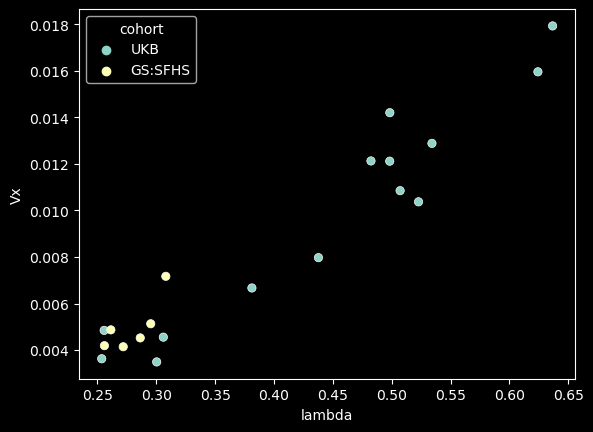

In [52]:
sns.scatterplot(
    data=df_mrg[df_mrg["weight"] == 2],
    x="lambda",
    y="Vx",
    hue="cohort"
)


In [ ]:
df_mrg.to_csv(
    "/data/jerrylee/pjt/BIGFAM.v.0.1/figures/data/X.BIGFAM.tsv",
    sep='\t',
    index=False
)

## Step 2.2 UKB vs. GCTA

In [35]:
df_mrg = pd.merge(
    df_ukb_filtered,
    df_gcta_filtered,
    on=["pheno"],
    suffixes=["_BIGFAM", "_GCTA"]
)

In [36]:
# regression & correlation
df_reg = pd.DataFrame(
    columns=[
        "weight", "n_pheno",
        "slope", "se_slope",
        "corr", "se_corr"
    ]
)

for weight in sorted(df_mrg["weight"].unique()):
    tmp = df_mrg[df_mrg["weight"] == weight].copy()
    
    ll = smf.ols(
        formula="Vx_BIGFAM ~ 0 + Vx_GCTA",
        data=tmp
    ).fit()
    
    # corr
    corrs = []
    for pheno in tmp["pheno"].unique():
        tmp_remove_one = tmp[tmp["pheno"] != pheno]
        corr = tmp_remove_one[["Vx_GCTA", "Vx_BIGFAM"]].corr().iloc[0, 1]
        corrs += [corr]
    
    df_reg.loc[len(df_reg)] = [
        weight, ll.nobs,
        ll.params["Vx_GCTA"], ll.bse["Vx_GCTA"], 
        np.mean(corrs), np.std(corrs)
    ]
df_reg.round(3)

,weight,n_pheno,slope,se_slope,corr,se_corr
0,-2.0,11.0,10.688,1.946,-0.660,0.047
1,-1.0,15.0,9.110,1.391,-0.429,0.053
2,0.0,17.0,6.242,0.641,-0.012,0.100
3,1.0,15.0,3.755,0.278,0.694,0.030
4,2.0,13.0,2.259,0.086,0.941,0.008
5,3.0,14.0,1.328,0.095,0.906,0.019
6,4.0,13.0,0.802,0.093,0.907,0.022
7,5.0,13.0,0.453,0.055,0.928,0.009
8,6.0,13.0,0.257,0.038,0.845,0.028
9,7.0,13.0,0.150,0.027,0.892,0.011


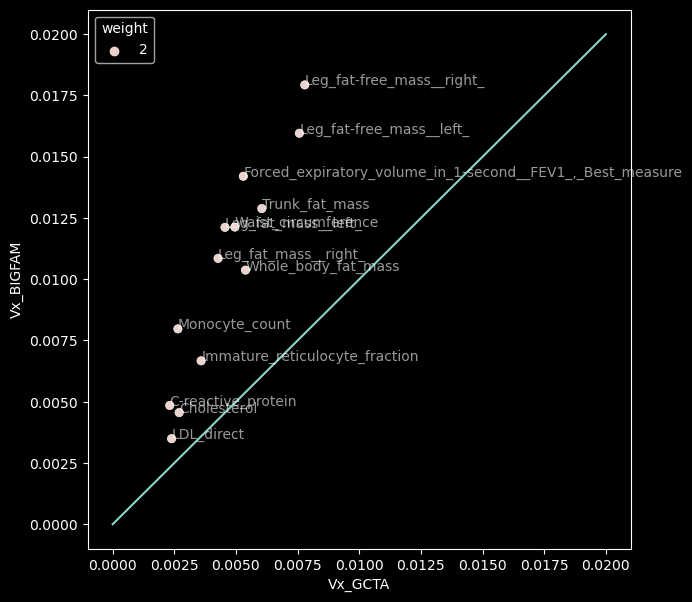

In [37]:
fig, ax = plt.subplots(figsize=(7, 7))

for_plot = df_mrg[df_mrg["weight"] == 2] #[(df_mrg["weight"] >= 1) & (df_mrg["weight"] < 4)],
sns.scatterplot(
    data=for_plot,
    x="Vx_GCTA",
    y="Vx_BIGFAM",
    hue="weight",
    ax=ax
)


ax.plot([0, 0.02], [0, 0.02])

for i, pheno in enumerate(for_plot["pheno"]):
    x = for_plot.loc[for_plot["pheno"] == pheno, "Vx_GCTA"].values[0]
    y = for_plot.loc[for_plot["pheno"] == pheno, "Vx_BIGFAM"].values[0]
    ax.annotate(pheno, (x, y), fontsize=10, alpha=0.6)

(-1.0, 3.0)

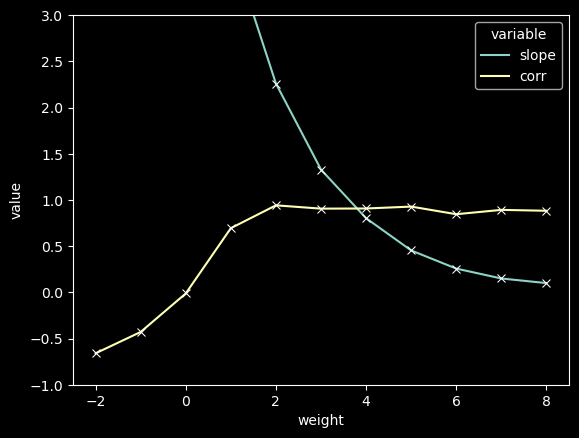

In [38]:
sns.lineplot(
    data=pd.melt(
        frame=df_reg,
        id_vars="weight",
        value_vars=["slope", "corr"]
    ),
    x="weight",
    y="value",
    hue="variable",
    marker="x"
)
plt.ylim([-1, 3])

In [ ]:
df_mrg.to_csv(
    "/data/jerrylee/pjt/BIGFAM.v.0.1/figures/data/vs_snp.X.filitered.tsv",
    sep='\t',
    index=False
)